In [1]:
import os
import glob
import numpy as np
import scipy.io as sio
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

/home/filipe/miniconda3/envs/redes_grafos/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class GestureSequenceDataset(Dataset):
    def __init__(self, root_dir, transform=None, pre_transform=None):
        super(GestureSequenceDataset, self).__init__(root_dir, transform, pre_transform)
        self.root_dir = root_dir
        self.mat_files = glob.glob(os.path.join(root_dir, '*.mat'))
        
        self.label_to_id = {} 
        self.current_id = 0 
        
        self.data_list = self._process_all_files()

    def _process_all_files(self):
        all_sequences = []
        
        for filepath in self.mat_files:
            mat_data = sio.loadmat(filepath, squeeze_me=True, struct_as_record=False)
            video = mat_data['Video']
            frames = np.atleast_1d(video.Frames)
            
            if not hasattr(video, 'Labels'):
                continue
                
            labels = np.atleast_1d(video.Labels)
            
            for segment in labels:
                nome_gesto = segment.Name
                start_idx = segment.Begin - 1
                end_idx = segment.End 
                
                frames_do_gesto = frames[start_idx:end_idx]
                
                sequencia_coordenadas = []
                
                for frame in frames_do_gesto:
                    if hasattr(frame, 'Skeleton') and hasattr(frame.Skeleton, 'PixelPosition'):
                        pos = frame.Skeleton.PixelPosition
                        if isinstance(pos, np.ndarray) and pos.ndim == 2 and pos.shape[0] == 20:
                            sequencia_coordenadas.append(pos)
                
                if len(sequencia_coordenadas) > 0:
                    
                    x_seq = torch.tensor(np.array(sequencia_coordenadas), dtype=torch.float)
                    
                    centro_de_massa = x_seq.mean(dim=1, keepdim=True) 

                    x_seq = x_seq - centro_de_massa

                    x_seq = x_seq / (x_seq.std() + 1e-5)

                    if nome_gesto not in self.label_to_id:
                        self.label_to_id[nome_gesto] = self.current_id
                        self.current_id += 1
                        
                    y_val = self.label_to_id[nome_gesto]
                    y = torch.tensor([y_val], dtype=torch.long)
                    
                    empty_edge_index = torch.empty((2, 0), dtype=torch.long)
                    
                    graph_data = Data(x=x_seq, edge_index=empty_edge_index, y=y)
                    all_sequences.append(graph_data)
                        
        return all_sequences

    def len(self):
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]

In [3]:
dataset = GestureSequenceDataset(root_dir='apenas_mats_train')

In [4]:
import torch
from torch.utils.data import random_split

total_amostras = len(dataset)

tamanho_treino = int(0.70 * total_amostras)
tamanho_val = int(0.15 * total_amostras)
tamanho_teste = total_amostras - tamanho_treino - tamanho_val 

print(f"Divisão: Treino ({tamanho_treino}), Validação ({tamanho_val}), Teste ({tamanho_teste})")

dataset_treino, dataset_val, dataset_teste = random_split(
    dataset, 
    [tamanho_treino, tamanho_val, tamanho_teste],
)

Divisão: Treino (5427), Validação (1163), Teste (1164)


In [5]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def preencher_lote_collate_fn(lista_de_grafos):
    xs = [grafo.x for grafo in lista_de_grafos] 
    ys = [grafo.y for grafo in lista_de_grafos] 
    
    tamanhos_reais = torch.tensor([len(x) for x in xs], dtype=torch.long)
    
    x_padded = pad_sequence(xs, batch_first=True, padding_value=0.0)
    
    y_batched = torch.cat(ys)
    
    return x_padded, y_batched, tamanhos_reais


loader_treino = DataLoader(
    dataset_treino, 
    batch_size=1024, 
    shuffle=True, 
    collate_fn=preencher_lote_collate_fn
)

loader_val = DataLoader(dataset_val, batch_size=1024, shuffle=False, collate_fn=preencher_lote_collate_fn)
loader_teste = DataLoader(dataset_teste, batch_size=1024, shuffle=False, collate_fn=preencher_lote_collate_fn)

In [6]:
def sharp_sigmoid(x, sharpness=50, threshold=0.1):
    return torch.sigmoid(sharpness * (x - threshold))

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import DenseGCNConv

class GestureGSLModel(nn.Module):
    def __init__(
        self,
        num_nodes=20,
        in_features=2,
        num_classes=20,
        hidden_dim=64
    ):
        super().__init__()

        adj = torch.rand((num_nodes, num_nodes)) * 0.04 + 0.01
        self.adj_param = nn.Parameter(adj)

        self.gcn1 = DenseGCNConv(in_features, hidden_dim)
        self.gcn2 = DenseGCNConv(hidden_dim, hidden_dim * 2)

        feat_dim = hidden_dim * 2

        self.temporal = nn.Sequential(
            nn.Conv1d(feat_dim, feat_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(feat_dim),
            nn.ReLU(),

            nn.Conv1d(feat_dim, feat_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(feat_dim),
            nn.ReLU(),

            nn.Conv1d(feat_dim, feat_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(feat_dim),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, feat_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(feat_dim // 2, num_classes)
        )

    def normalize_adj(self, adj):
        adj = (adj + adj.t()) / 2

        eye = torch.eye(adj.size(0), device=adj.device)
        adj = adj + eye

        deg = adj.sum(-1)
        deg_inv = deg.pow(-0.5)
        deg_inv[torch.isinf(deg_inv)] = 0

        return deg_inv[:, None] * adj * deg_inv[None]

    def forward(self, x_padded, mask):

        B, T, N, C = x_padded.shape

        adj = sharp_sigmoid(self.adj_param, 5, 0.1)
        adj = self.normalize_adj(adj)

        adj_batch = adj.unsqueeze(0).expand(B*T, N, N)

        x = x_padded.view(B*T, N, C)

        x = F.relu(self.gcn1(x, adj_batch, add_loop=False))
        x = F.relu(self.gcn2(x, adj_batch, add_loop=False))

        x = x.view(B, T, N, -1)

        x = x * mask.unsqueeze(-1).unsqueeze(-1)

        # Pool espacial
        x = x.mean(dim=2)

        # (B,T,F) -> (B,F,T)
        x = x.transpose(1, 2)

        # CNN temporal
        x = self.temporal(x)

        # máscara temporal
        mask = mask.unsqueeze(1)
        x = x * mask

        # média apenas dos frames válidos
        x = x.sum(-1) / mask.sum(-1).clamp(min=1)

        out = self.classifier(x)

        return out


In [8]:
lote_x, lote_y, lote_tamanhos = next(iter(loader_treino))

print(f"Shape do Lote X preenchido: {lote_x.shape} -> [Tamanho do Lote, Maior T do Lote, 20, 2]")
print(f"Labels do Lote Y: {lote_y.shape}")
print(f"Tamanhos reais antes do zero: {lote_tamanhos}")

Shape do Lote X preenchido: torch.Size([1024, 109, 20, 2]) -> [Tamanho do Lote, Maior T do Lote, 20, 2]
Labels do Lote Y: torch.Size([1024])
Tamanhos reais antes do zero: tensor([26, 67, 60,  ..., 60, 80, 35])


In [ ]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    loss_treino_acumulada = 0.0
    acertos_treino = 0
    total_treino = 0
    
    for x_padded, y_batched, tamanhos_reais in loader:
        x_padded = x_padded.to(device)
        y_batched = y_batched.to(device)
        tamanhos_reais = tamanhos_reais.to(device)
        
        B, T = x_padded.shape[0], x_padded.shape[1]
        posicoes = torch.arange(T, device=device).unsqueeze(0).expand(B, T)
        mask = posicoes < tamanhos_reais.unsqueeze(1)
        
        optimizer.zero_grad()
        
        previsoes = model(x_padded, mask)
        
        loss = criterion(previsoes, y_batched)  + sharp_sigmoid(model.adj_param, 5, 0.1).sum() * 0.0000025
        # loss = criterion(previsoes, y_batched)  + F.relu(model.adj_param).sum() * 0.000005
        
        loss.backward()
        
        optimizer.step()
        
        loss_treino_acumulada += loss.item()
        
        _, classe_prevista = torch.max(previsoes, 1)
        acertos_treino += (classe_prevista == y_batched).sum().item()
        total_treino += y_batched.size(0)

    acc_treino = acertos_treino / total_treino
    loss_media_treino = loss_treino_acumulada / len(loader)
    
    return loss_media_treino, acc_treino

def evaluate(model, loader, criterion, device):
    model.eval()
    loss_val_acumulada = 0.0
    acertos_val = 0
    total_val = 0
    
    with torch.no_grad(): 
        for x_padded, y_batched, tamanhos_reais in loader:
            x_padded = x_padded.to(device)
            y_batched = y_batched.to(device)
            
            tamanhos_reais = tamanhos_reais.to(device)
            
            B, T = x_padded.shape[0], x_padded.shape[1]
            posicoes = torch.arange(T, device=device).unsqueeze(0).expand(B, T)
            mask = posicoes < tamanhos_reais.unsqueeze(1)
            
            previsoes = model(x_padded, mask)
            loss = criterion(previsoes, y_batched)
            
            loss_val_acumulada += loss.item()
            _, classe_prevista = torch.max(previsoes, 1)
            acertos_val += (classe_prevista == y_batched).sum().item()
            total_val += y_batched.size(0)
            
    acc_val = acertos_val / total_val
    loss_media_val = loss_val_acumulada / len(loader)
    
    return loss_media_val, acc_val

Treinando na unidade: cuda


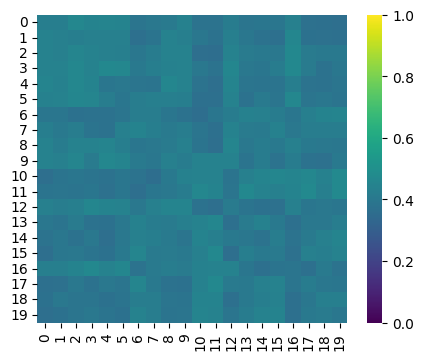

Época [1/1000] | Loss Treino: 3.0120 - Acc Treino: 0.0503 | Loss Val: 2.9938 - Acc Val: 0.0473 |


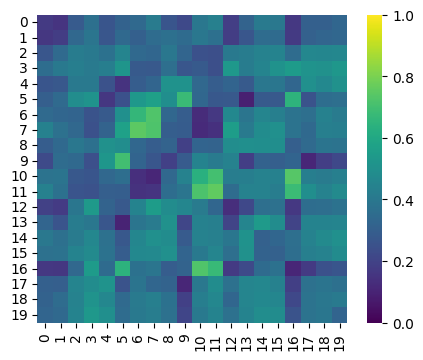

Época [21/1000] | Loss Treino: 1.9822 - Acc Treino: 0.3256 | Loss Val: 2.3581 - Acc Val: 0.2201 |


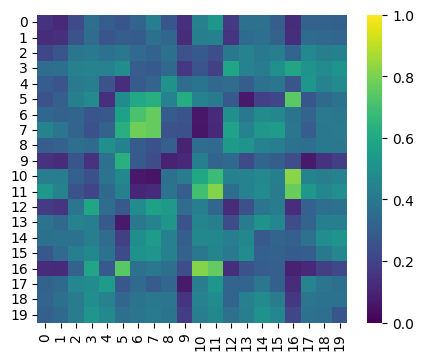

Época [41/1000] | Loss Treino: 1.6560 - Acc Treino: 0.4290 | Loss Val: 2.8334 - Acc Val: 0.1728 |


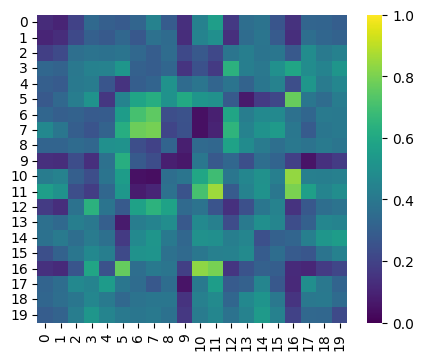

Época [61/1000] | Loss Treino: 1.4607 - Acc Treino: 0.4970 | Loss Val: 2.4340 - Acc Val: 0.2365 |


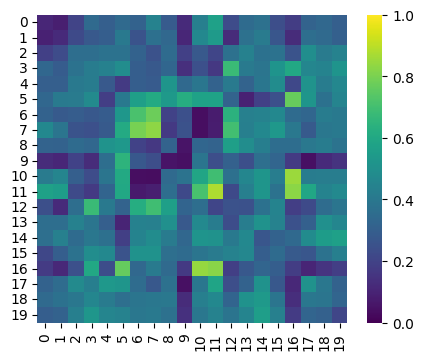

Época [81/1000] | Loss Treino: 1.3125 - Acc Treino: 0.5489 | Loss Val: 9.0914 - Acc Val: 0.1505 |


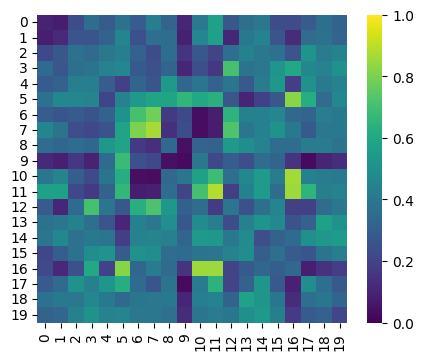

Época [101/1000] | Loss Treino: 1.1496 - Acc Treino: 0.6142 | Loss Val: 2.7769 - Acc Val: 0.2330 |


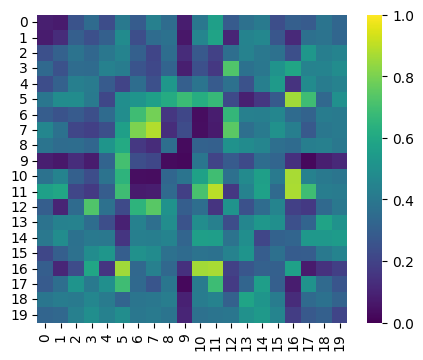

Época [121/1000] | Loss Treino: 1.0945 - Acc Treino: 0.6318 | Loss Val: 1.9867 - Acc Val: 0.4136 |


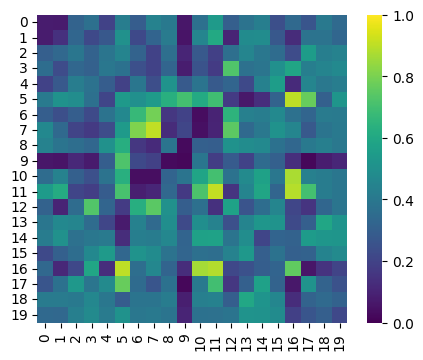

Época [141/1000] | Loss Treino: 0.9853 - Acc Treino: 0.6718 | Loss Val: 4.3256 - Acc Val: 0.2296 |


In [ ]:
import torch.optim as optim
import torch.nn as nn

model = GestureGSLModel(num_nodes=20, in_features=2, num_classes=20,hidden_dim=64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando na unidade: {device}")

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.005)

num_epocas = 1000
intervalo = 20
loss_history = []
val_loss_history = []


for epoca in range(num_epocas):
    loss_media_treino, acc_treino = train(model, loader_treino, optimizer, criterion, device)
    
    loss_media_val, acc_val = evaluate(model, loader_val, criterion, device)
    
    loss_history.append(loss_media_treino)
    val_loss_history.append(loss_media_val)
    if epoca % 20 == 0 or epoca == 0:
        adj = sharp_sigmoid(model.adj_param,5,0.1).detach().cpu().numpy()
        # adj = F.relu(model.adj_param).detach().cpu().numpy()
        plt.figure(figsize=(5, 4))
        sns.heatmap(adj, cmap="viridis", vmin=0, vmax=1)
        plt.show()
        print(f"Época [{epoca+1}/{num_epocas}] | "
            f"Loss Treino: {loss_media_treino:.4f} - Acc Treino: {acc_treino:.4f} | "
            f"Loss Val: {loss_media_val:.4f} - Acc Val: {acc_val:.4f} |")


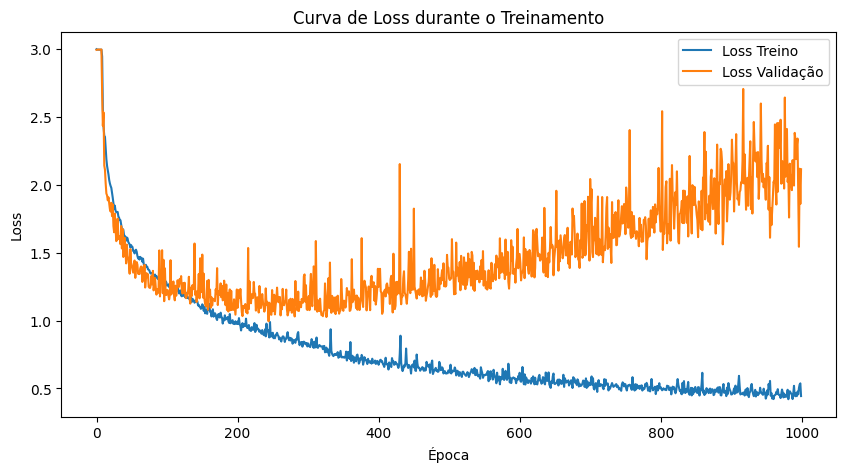

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Loss Treino')
plt.plot(val_loss_history, label='Loss Validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de Loss durante o Treinamento')
plt.legend()
plt.show()

In [ ]:
test_loss,test_acc = evaluate(model,loader_teste,criterion,"cuda")
print(f"Acc test: {test_acc}")

Acc test: 0.7757731958762887


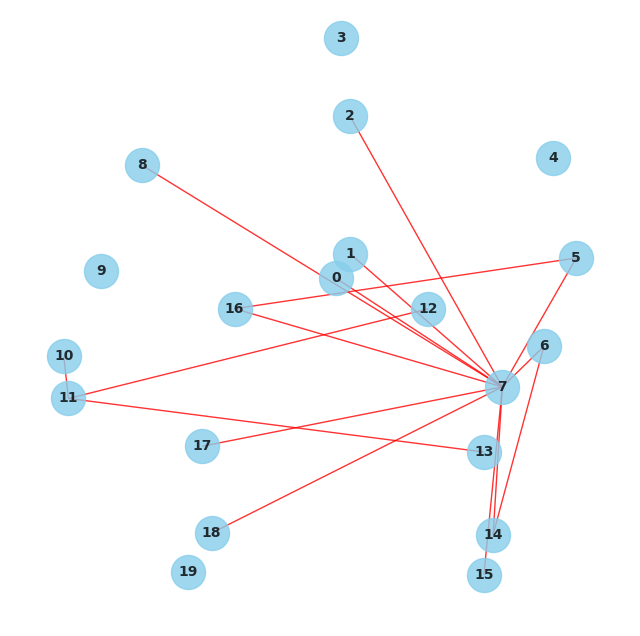

In [ ]:
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data 
from torch_geometric.utils import to_networkx

model.eval()
adj_aprendida = sharp_sigmoid(model.adj_param,30,0.1).detach().cpu()
# adj_aprendida = F.relu(model.adj_param).detach().cpu()

limiar = 0.7
adj_filtrada = torch.where(adj_aprendida > limiar, torch.tensor(1.0), torch.tensor(0.0))

edge_index, _ = dense_to_sparse(adj_filtrada)
data_view = Data(edge_index=edge_index, num_nodes=20)
G = to_networkx(data_view, to_undirected=True)

amostra_base = dataset_teste[1]
coordenadas_reais = amostra_base.x[1].numpy()

posicoes_esqueleto = {i: (coordenadas_reais[i, 0], coordenadas_reais[i, 1]) for i in range(20)}

plt.figure(figsize=(8, 8))
plt.axis('off')

nx.draw_networkx(
    G,
    pos=posicoes_esqueleto, 
    with_labels=True,
    node_size=600,
    node_color="skyblue",
    font_size=10,
    font_weight="bold",
    edge_color="red",     
    width=1.0,            
    alpha=0.8
)

plt.gca().invert_yaxis()
plt.show()